### 01. Exploratory Data Analysis (EDA)

**Dataset   :** IBM  Telco Customer Churn

**Rows      :** 7,043 customers

**Columns   :** 21 features + 1 target

**Goal      :** Understand the data sturcture, quality, distributions, and which features relate most strongly to churn before any preprocessing or modeling.

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Makes all plots look clean and consistent
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 130

In [19]:
df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

print(f"Shape: {df.shape}")
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

#### Data quality obsevations from '.info()'

- `TotalCharges` is type `object` instead of `float64`. This indicates non-numeric values are present (likely empty strings for new customers with zero charges). Needs convesion and null handling.

- `customerID` is a unique identifier - not a feature, will be dropped before modelling

- All other columns appear to have the correct dtype at first glance.

In [21]:
# Convert TotalCharges to numeric - blank strings become NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

#Count missing values per column
missing = df.isnull().sum()
missing = missing[missing > 0]
print('Column with missing values: ')
print(missing)
print(f'Total missing: {missing.sum()} rows ({missing.sum()/len(df)*100:.2f}% of of dataset)')

Column with missing values: 
TotalCharges    11
dtype: int64
Total missing: 11 rows (0.16% of of dataset)


In [22]:
df[df['TotalCharges'].isnull()][['tenure','MonthlyCharges','TotalCharges']]

,tenure,MonthlyCharges,TotalCharges
488,0,52.55,NaN
753,0,20.25,NaN
936,0,80.85,NaN
1082,0,25.75,NaN
1340,0,56.05,NaN
3331,0,19.85,NaN
3826,0,25.35,NaN
4380,0,20.00,NaN
5218,0,19.70,NaN
6670,0,73.35,NaN


All rows have `tenure = 0`. Confirm that they are brand new customers.

In [23]:
#Encode the target variable
#Convert Churn from 'Yes/No' to 1/0 for analysis

df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})
print(df['Churn'].value_counts())
print(f"\nChurn rate: {df['Churn'].mean()*100:.1f}%")

Churn
0    5174
1    1869
Name: count, dtype: int64

Churn rate: 26.5%


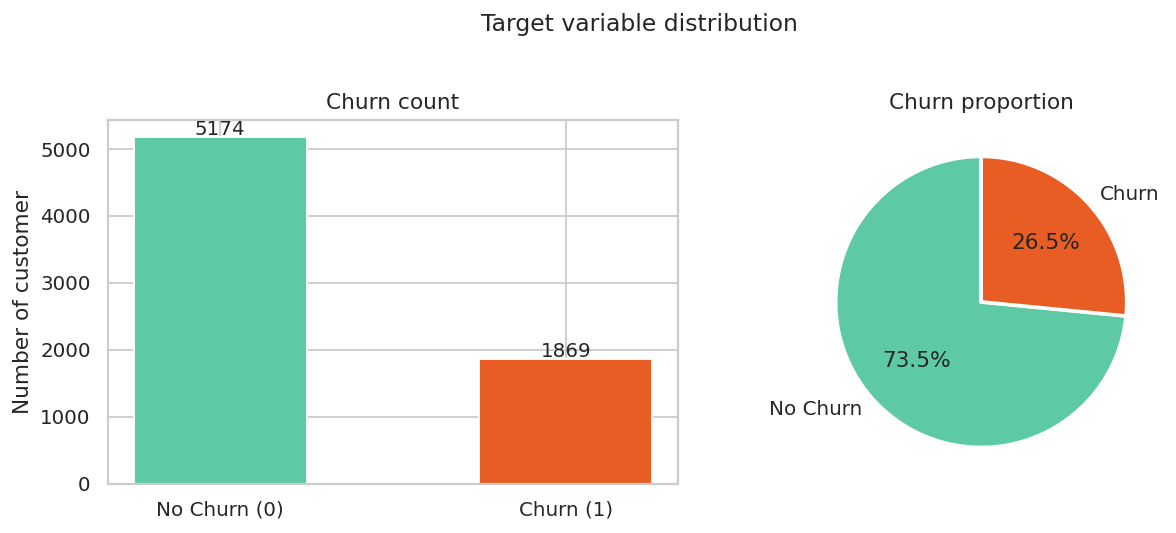

In [24]:
fig, axes = plt.subplots(1,2, figsize=(10,4))

# Left : count plot
counts = df['Churn'].value_counts()
axes[0].bar(['No Churn (0)', 'Churn (1)'], counts.values, color=["#5DCAA5", "#E85D24"], width=0.5)
axes[0].set_title('Churn count')
axes[0].set_ylabel('Number of customer')
for i, v in enumerate(counts.values):
    axes[0].text(i,v + 30, str(v), ha="center", fontsize=11)

#Right percentage pie 
axes[1].pie(counts.values, labels=['No Churn', 'Churn'],
            autopct='%1.1f%%', colors=["#5DCAA5", "#E85D24"],
            startangle=90, wedgeprops={"edgecolor": "white", "linewidth": 2})
axes[1].set_title("Churn proportion")

plt.suptitle("Target variable distribution", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("/workspaces/telcom-customers-churn/docs/figures/01_churn_distribution.png", bbox_inches="tight")
plt.show()

### Target variable: class imbalance

The dataset has a 73.5% / 26.5% split (no churn / churn). This is a moderate class imbalance. Key implication:
- *Do not use accuracy* as the evaluation metric
- Use *AUC-ROC* as the primary metric (robust to imbalance)
- Apply *SMOTE* during training to synthetically balance classes
- Lower the decision threshold to 0.4 to favor recall

#### Analyse numeric features

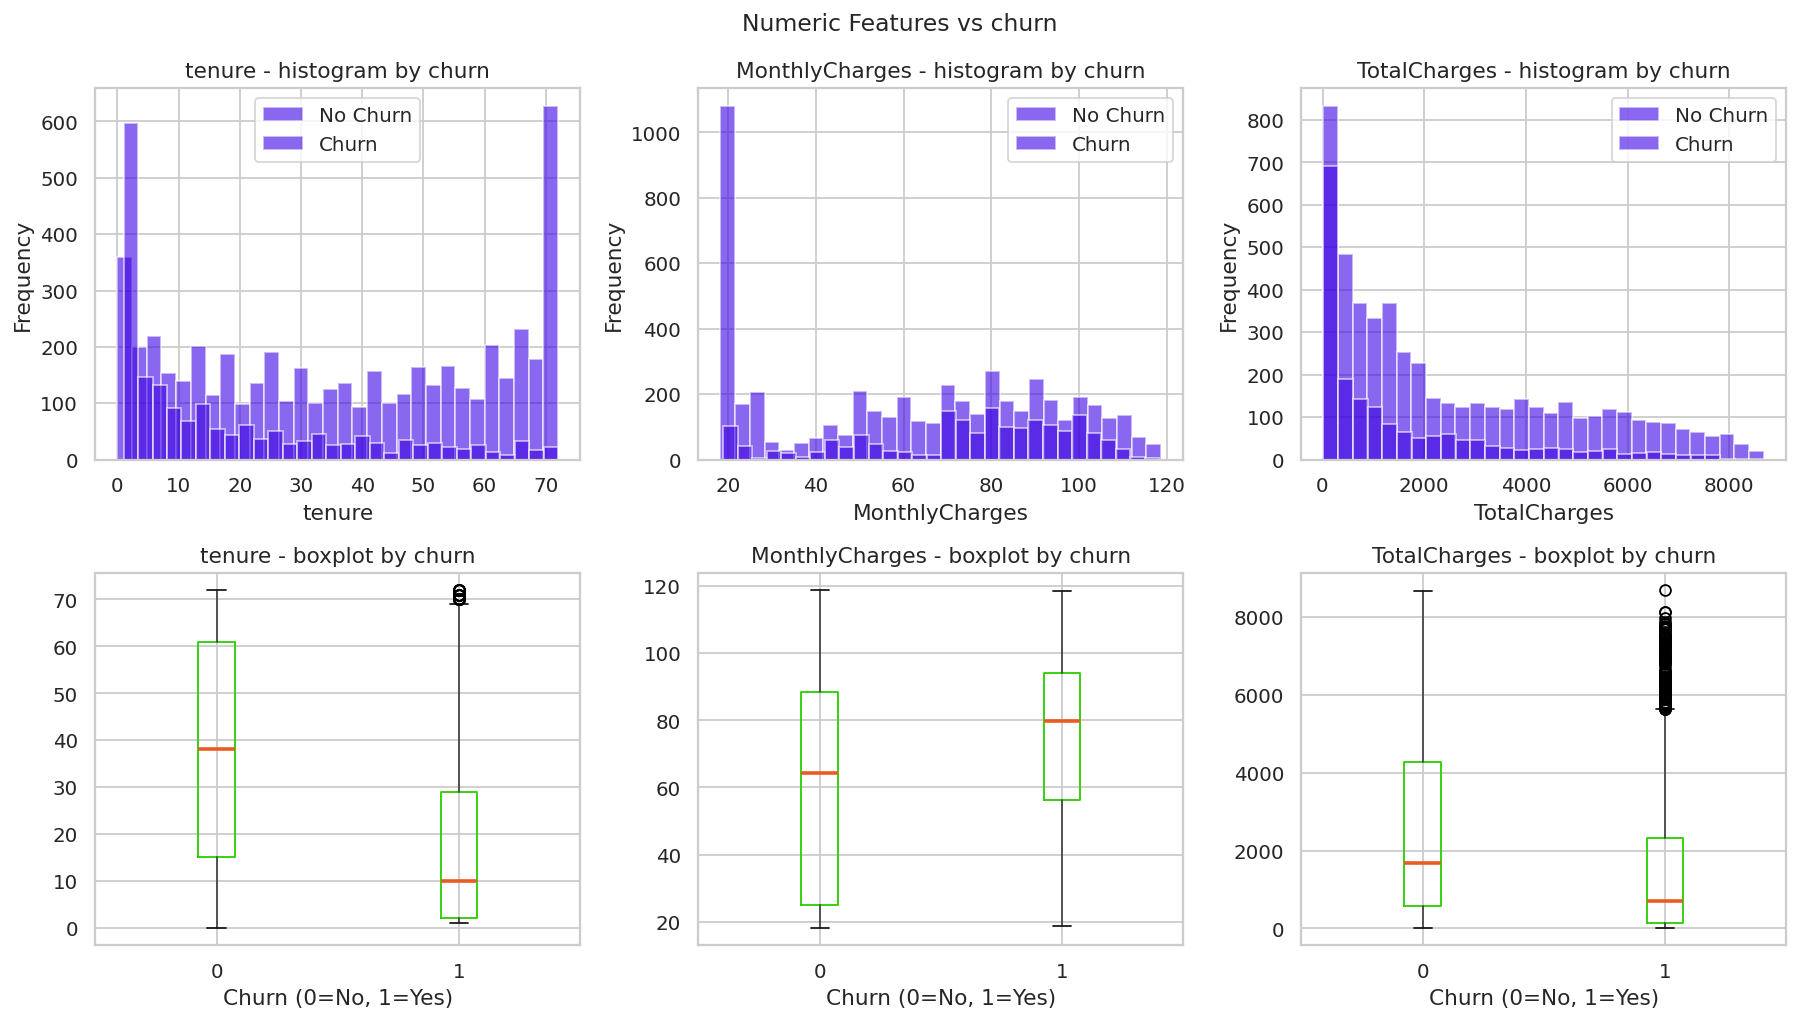

In [31]:
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(2,3, figsize=(14,8))

for i, col, in enumerate(numeric_cols):
    # Top row: histogram by churn
    df.groupby('Churn')[col].plot(kind="hist", ax=axes[0, i], 
                                  alpha=0.6, bins=30, legend=True, 
                                  color=["#3B02E3", "#984423"])
    axes[0, i].set_title(f'{col} - histogram by churn')
    axes[0, i].set_xlabel(col)
    axes[0, i].legend(['No Churn','Churn'])

    #Bottom row: boxplot by churn
    df.boxplot(column=col, by='Churn', ax=axes[1,i],
               boxprops=dict(color="#29CD00"),
               medianprops=dict(color="#E85D24", linewidth=2))
    axes[1,i].set_title(f'{col} - boxplot by churn')
    axes[1,i].set_xlabel('Churn (0=No, 1=Yes)')
plt.suptitle('Numeric Features vs churn', fontsize=13)
plt.tight_layout()
plt.savefig("/workspaces/telcom-customers-churn/docs/figures/02_numeric_distributions.png", bbox_inches="tight")
plt.show()

#### Numeric features — findings

| Feature | Churners | Non-churners | Implication |
|---|---|---|---|
| `tenure` | Median ~10 months | Median ~38 months | Short-tenure = highest risk |
| `MonthlyCharges` | Median ~$79 | Median ~$61 | Higher bills → more likely to leave |
| `TotalCharges` | Lower overall | Higher overall | Driven by tenure, not independent |

`tenure` is likely the most predictive numeric feature. `TotalCharges` is
highly correlated with `tenure × MonthlyCharges` and may be dropped or
used to engineer a new feature.

#### Analyse categorical features

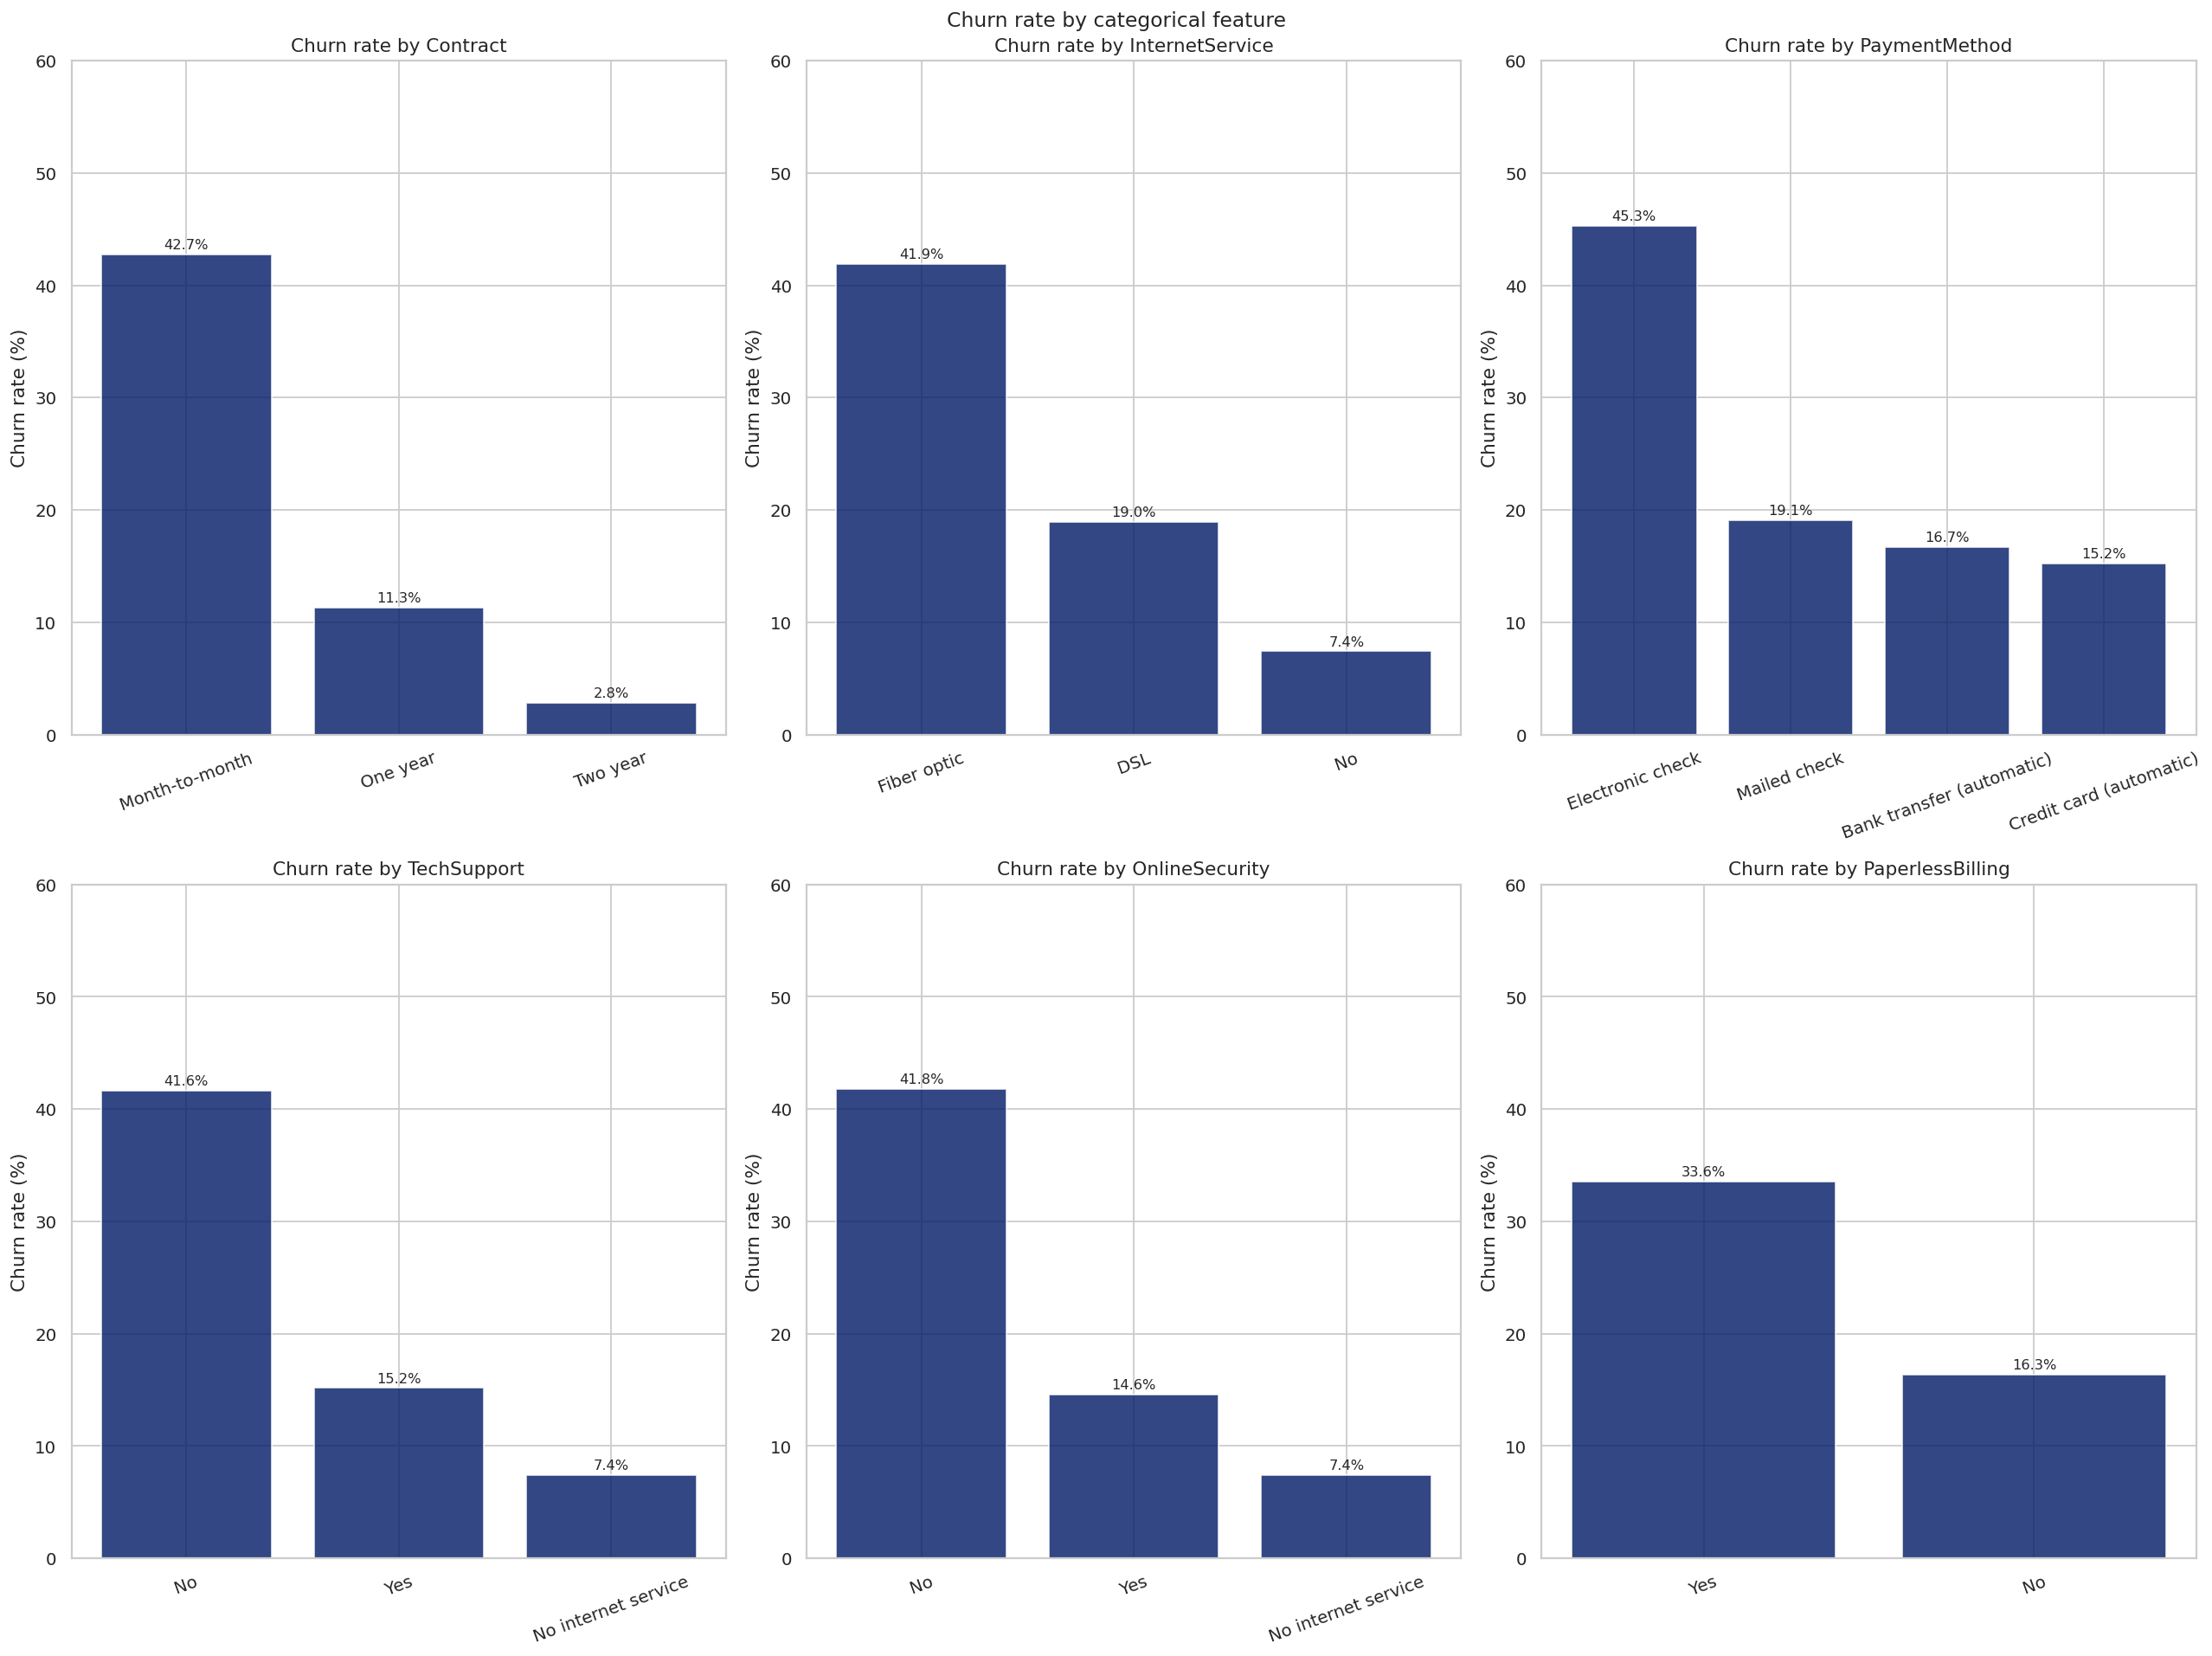

In [41]:
cat_cols = ['Contract', 'InternetService', 'PaymentMethod',
            'TechSupport', 'OnlineSecurity', 'PaperlessBilling']

fig, axes = plt.subplots(2,3, figsize=(20,15))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    churn_rate = df.groupby(col)['Churn'].mean().sort_values(ascending=False)
    bars = axes[i].bar(churn_rate.index, churn_rate.values * 100,
                       color="#001965", alpha=0.8, edgecolor="white")
    axes[i].set_title(f'Churn rate by {col}')
    axes[i].set_ylabel('Churn rate (%)')
    axes[i].set_ylim(0,60)
    axes[i].tick_params(axis='x', rotation=20)
    for bar, val in zip(bars, churn_rate.values):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.5,
                     f"{val*100:.1f}%", ha="center", fontsize=9)

plt.suptitle("Churn rate by categorical feature", fontsize=13)
plt.tight_layout()
plt.savefig("/workspaces/telcom-customers-churn/docs/figures/03_categorical_churn_rates.png", bbox_inches="tight")
plt.show()


#### Correlation heatmap

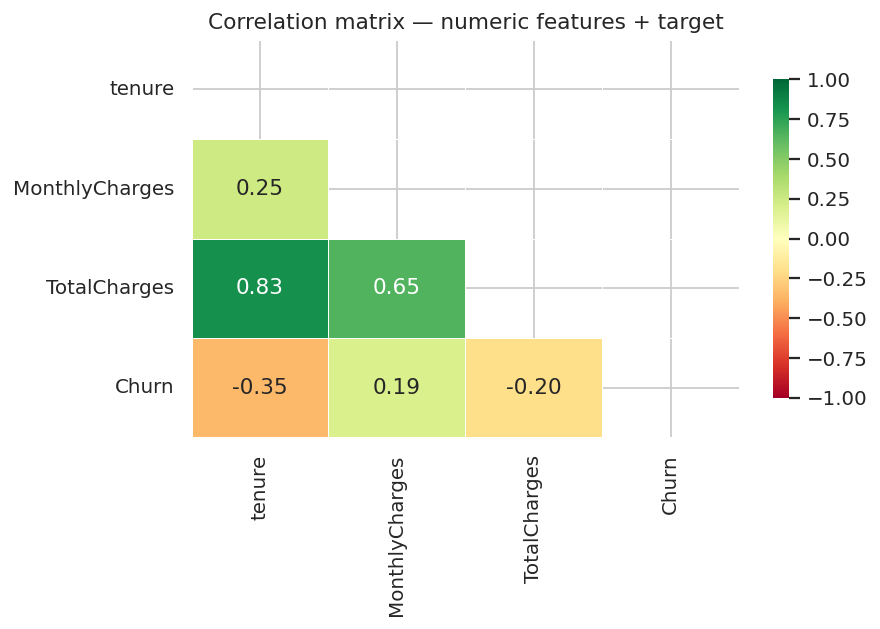

In [42]:
# Create a numeric-only version for correlation analysis
df_numeric = df[numeric_cols + ["Churn"]].copy()

fig, ax = plt.subplots(figsize=(7, 5))
corr = df_numeric.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # hide upper triangle (redundant)

sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdYlGn",
            center=0, vmin=-1, vmax=1, ax=ax,
            linewidths=0.5, cbar_kws={"shrink": 0.8})

ax.set_title("Correlation matrix — numeric features + target", fontsize=12)
plt.tight_layout()
plt.savefig("/workspaces/telcom-customers-churn/docs/figures/04_correlation_heatmap.png", bbox_inches="tight")
plt.show()

In [43]:
# customerID is a unique identifier — no predictive value
df = df.drop(columns=["customerID"])
print(f"customerID dropped. Final shape: {df.shape}")

# Quick summary statistics
df[numeric_cols].describe().round(2)

customerID dropped. Final shape: (7043, 20)


,tenure,MonthlyCharges,TotalCharges
count,7043.00,7043.00,7032.00
mean,32.37,64.76,2283.30
std,24.56,30.09,2266.77
min,0.00,18.25,18.80
25%,9.00,35.50,401.45
50%,29.00,70.35,1397.48
75%,55.00,89.85,3794.74
max,72.00,118.75,8684.80


## EDA Summary — key findings

### Data quality
- 11 missing values in `TotalCharges` (0.16% of data) — all are new customers
  with tenure = 0. Will impute with 0 in preprocessing.
- `customerID` dropped — unique identifier, not a feature.
- No other missing values detected.

### Class imbalance
- 26.5% churn rate. Moderate imbalance.
- Will use AUC-ROC as primary metric. Will apply SMOTE during training.

### Most predictive features (based on EDA)
1. `Contract` — month-to-month customers churn at 42% vs 3% for 2-year contracts
2. `tenure` — strongest numeric predictor; median churner tenure is ~10 months
3. `InternetService` — fibre optic customers churn at 41%
4. `MonthlyCharges` — churners pay ~$18/month more on average
5. `OnlineSecurity` / `TechSupport` — absence doubles churn rate

### Feature engineering ideas for Phase 3
- Create `tenure_bin`: new (0–12m), mid (13–36m), loyal (37m+)
- Consider dropping `TotalCharges` (0.83 correlation with tenure — multicollinearity risk)
- Consider interaction feature: `MonthlyCharges × Contract_type`

### Next step
→ `02_feature_engineering.ipynb` — encode categoricals, scale numerics,
  handle nulls, and build the sklearn preprocessing pipeline.